# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Rayhan Lutfi Hakim| 5054251043|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [32]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("D:\ML\Praktikum_Naive Bayes\diabetes.csv")
print("deskripsi",df.describe())
print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:", df.dtypes)
print("\nJumlah missing value:", df.isnull().sum())

deskripsi        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.369578   30.464161      12.106039       8.890820   89.100847   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  102.500000   
50%       3.000000  117.000000      72.000000      28.000000  102.500000   
75%       6.000000  140.250000      80.000000      32.000000  169.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.434635                  0.471876   33.240885    0.348958  
std      6.880498                  0.331329   11.760232    0.476951  
min     18.200000        

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\M S I\AppData\Local\Temp\ipykernel_21052\4281334952.py:2: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("D:\ML\Praktikum_Naive Bayes\diabetes.csv")


C:\Users\M S I\AppData\Local\Temp\ipykernel_21052\2184801042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


Jumlah sampel per kelas:
 Outcome
0    500
1    268
Name: count, dtype: int64


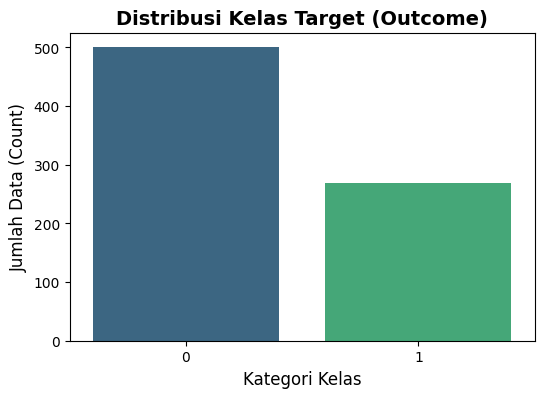

In [4]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_counts = df['Outcome'].value_counts()
print("Jumlah sampel per kelas:\n", target_counts)

# 2. Membuat Bar Plot menggunakan Seaborn
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')

# 3. Menambahkan Judul dan Label agar grafik informatif
plt.title('Distribusi Kelas Target (Outcome)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kelas', fontsize=12)
plt.ylabel('Jumlah Data (Count)', fontsize=12)

# 4. Menampilkan Grafik
plt.show()

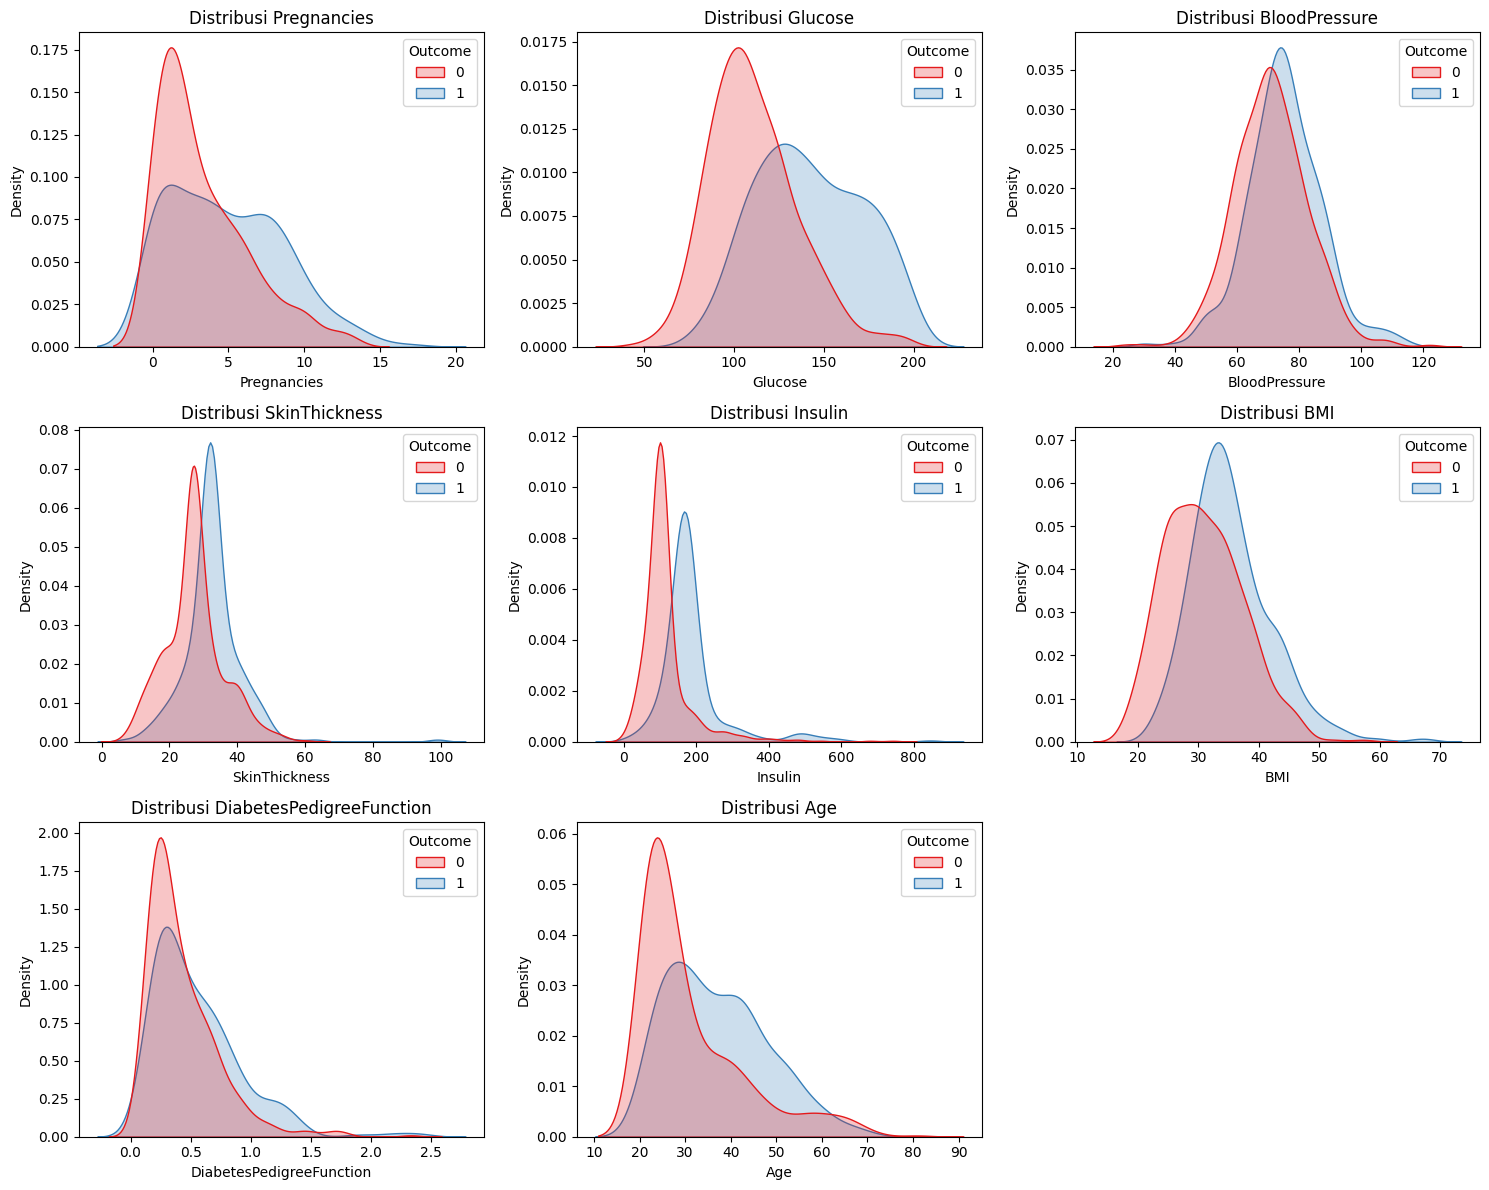

In [ ]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.columns.drop('Outcome')
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
# Melakukan iterasi (perulangan) untuk membuat plot di setiap fitur
for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, ax=axes[i], palette='Set1', common_norm=False)
    axes[i].set_title(f'Distribusi {col}')
# Menghapus kanvas kosong (karena hanya ada 8 fitur, sedangkan kanvas ada 9)
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

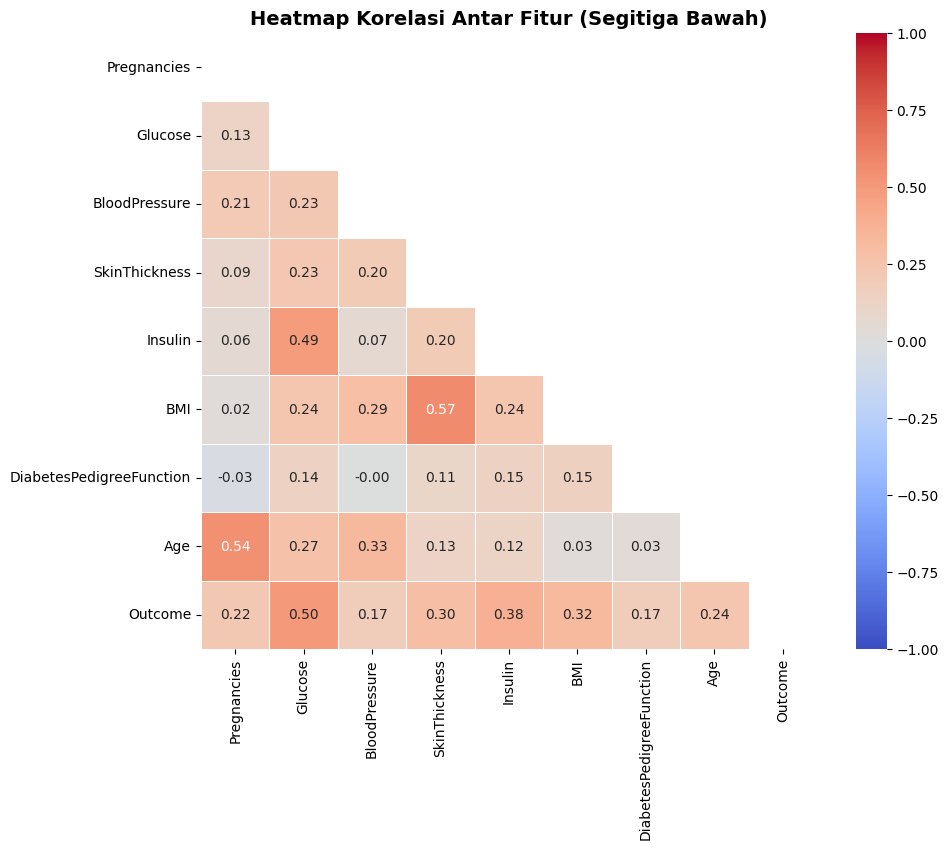

In [20]:
# Tampilkan heatmap korelasi antar fitur.
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur (Segitiga Bawah)', fontsize=14, fontweight='bold')
plt.show()

C:\Users\M S I\AppData\Local\Temp\ipykernel_21052\1525528433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_outcome.values, y=corr_with_outcome.index, palette='viridis')


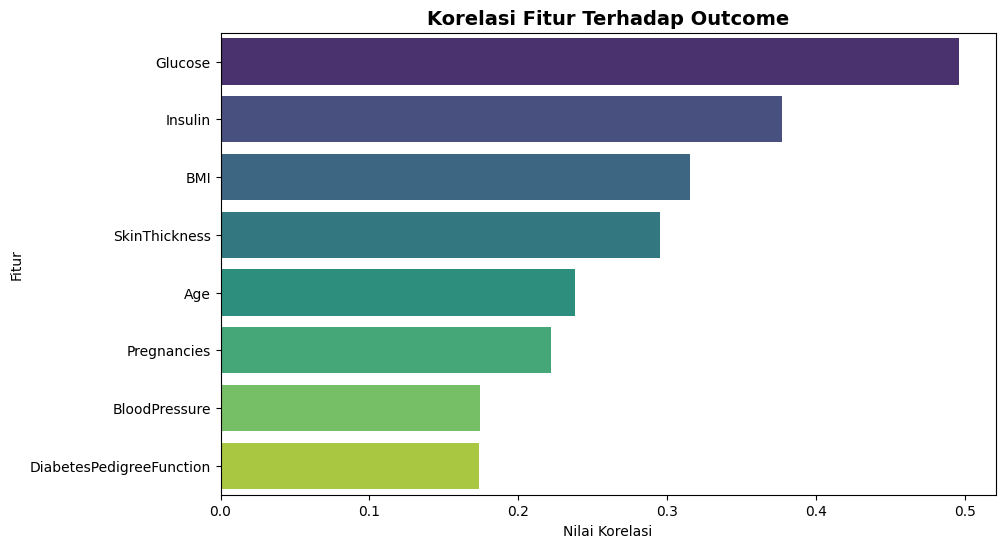

In [21]:
corr_with_outcome = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_outcome.values, y=corr_with_outcome.index, palette='viridis')
plt.title('Korelasi Fitur Terhadap Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Fitur')
plt.show()

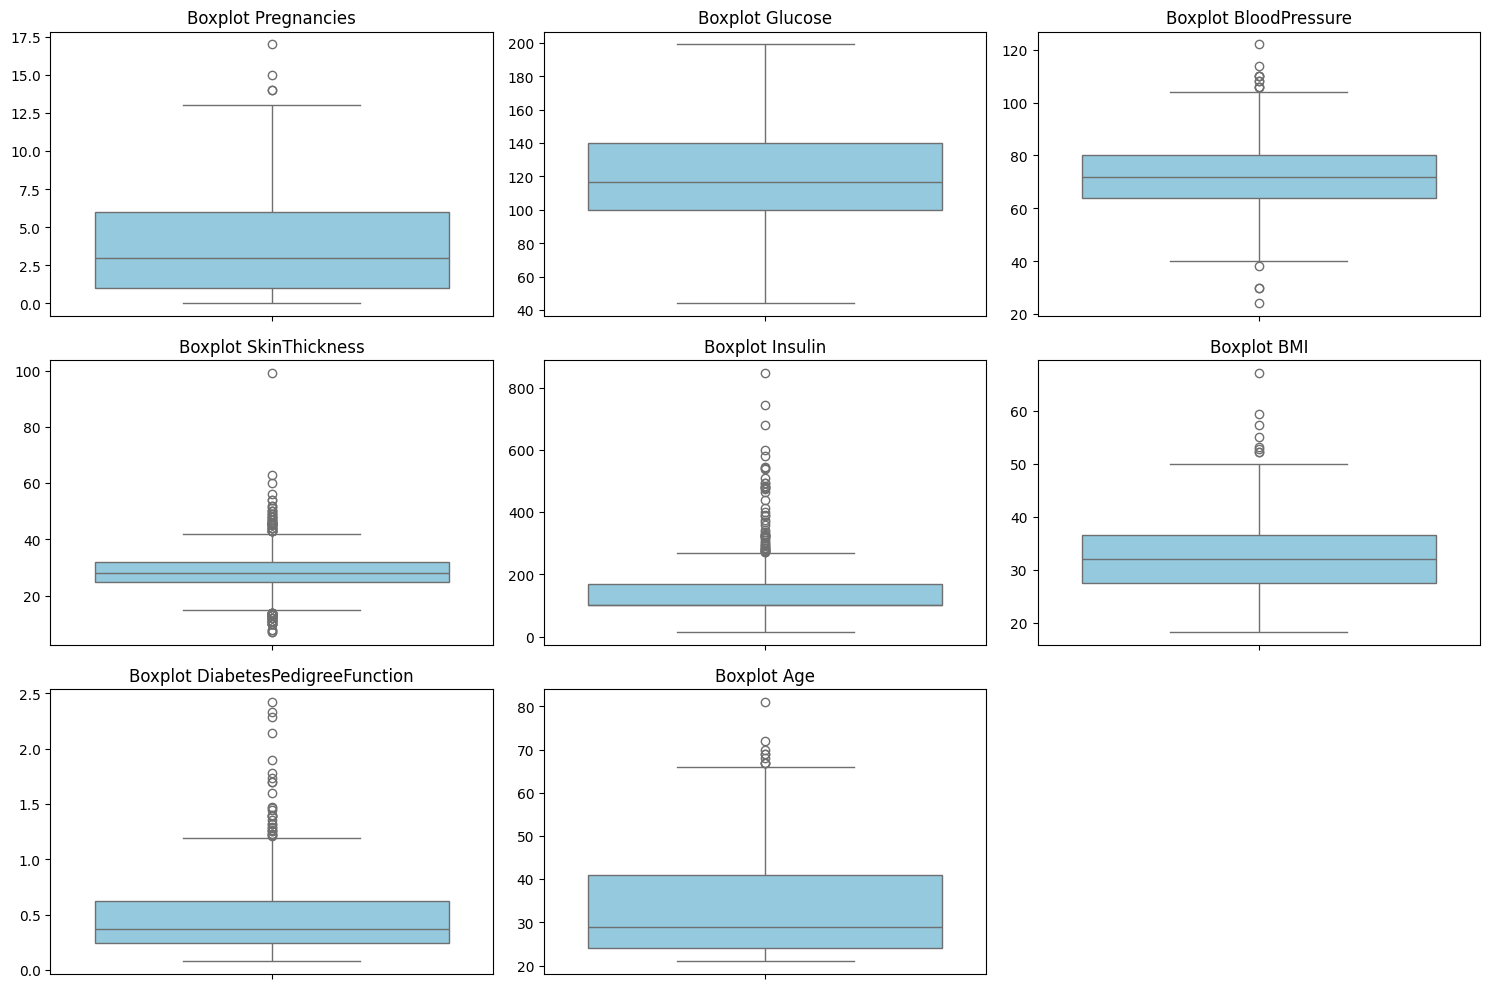

In [22]:
features = df.columns.drop('Outcome')
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [25]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Mengecek dan menghitung jumlah nilai 0 pada setiap kolom
print("Jumlah data bernilai 0:")
for col in cols_to_check:
    count_zero = (df[col] == 0).sum()
    print(f"- {col}: {count_zero} baris")

Jumlah data bernilai 0:
- Glucose: 0 baris
- BloodPressure: 0 baris
- SkinThickness: 0 baris
- Insulin: 0 baris
- BMI: 0 baris


In [26]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_zeros = 0
for col in cols_to_check:
    count_zero = (df[col] == 0).sum()
    total_zeros += count_zero
    
    # Hanya cetak jika ada nilai 0 di kolom tersebut
    if count_zero > 0:
        print(f"- Kolom {col} memiliki {count_zero} nilai 0")
# Kondisi jika secara keseluruhan tidak ditemukan nilai 0 sama sekali
if total_zeros == 0:
    print("Tidak ada fitur yang memiliki nilai 0 dalam data.")

Tidak ada fitur yang memiliki nilai 0 dalam data.


In [27]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,     
    stratify=y,         
    random_state=42     
)
# Menampilkan jumlah baris untuk memastikan data terbagi dengan benar
print(f"Jumlah data keseluruhan : {len(df)} baris")
print(f"Jumlah data latih (Train) : {len(X_train)} baris")
print(f"Jumlah data uji (Test)    : {len(X_test)} baris")

Jumlah data keseluruhan : 768 baris
Jumlah data latih (Train) : 614 baris
Jumlah data uji (Test)    : 154 baris


In [29]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
print("Contoh 5 baris pertama X_train yang sudah di-scaling:")
display(X_train_scaled.head())

Contoh 5 baris pertama X_train yang sudah di-scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
1,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
2,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
3,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
4,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [30]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
# 2. Latih (fit) model menggunakan train set
gnb.fit(X_train_scaled, y_train)
print("Model Gaussian Naive Bayes berhasil dilatih!")

Model Gaussian Naive Bayes berhasil dilatih!


In [31]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]
# Cek hasil prediksi 5 data pertama
print("Contoh 5 Hasil Prediksi (GNB):", y_pred_gnb[:5])
print("Contoh 5 Probabilitas Kelas 1 (GNB):", y_prob_gnb[:5])

Contoh 5 Hasil Prediksi (GNB): [0 0 0 0 0]
Contoh 5 Probabilitas Kelas 1 (GNB): [0.39463909 0.21090162 0.23283517 0.18530596 0.00605332]


## 3.2 Logistic Regression

In [34]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(max_iter=1000, random_state=42)
# 2. Latih (fit) model menggunakan train set
logreg.fit(X_train_scaled, y_train)
print("Model Logistic Regression berhasil dilatih!")

Model Logistic Regression berhasil dilatih!


In [35]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = logreg.predict(X_test_scaled)
# 2. Simpan probabilitas khusus untuk kelas 1 (Diabetes)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
# Cek hasil prediksi 5 data pertama
print("Contoh 5 Hasil Prediksi (LogReg):", y_pred_logreg[:5])
print("Contoh 5 Probabilitas Kelas 1 (LogReg):", y_prob_logreg[:5])

Contoh 5 Hasil Prediksi (LogReg): [0 0 0 0 0]
Contoh 5 Probabilitas Kelas 1 (LogReg): [0.47739551 0.07407477 0.37011559 0.33773074 0.03196289]


# 4. Evaluasi Model

In [36]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def print_metrics(model_name, y_true, y_pred):
    print(f"--- Metrik Evaluasi: {model_name} ---")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}\n")
# Cetak hasil untuk kedua model
print_metrics("Gaussian Naive Bayes", y_test, y_pred_gnb)
print_metrics("Logistic Regression", y_test, y_pred_logreg)

--- Metrik Evaluasi: Gaussian Naive Bayes ---
Accuracy  : 0.7273
Precision : 0.6034
Recall    : 0.6481
F1-Score  : 0.6250

--- Metrik Evaluasi: Logistic Regression ---
Accuracy  : 0.7078
Precision : 0.5882
Recall    : 0.5556
F1-Score  : 0.5714



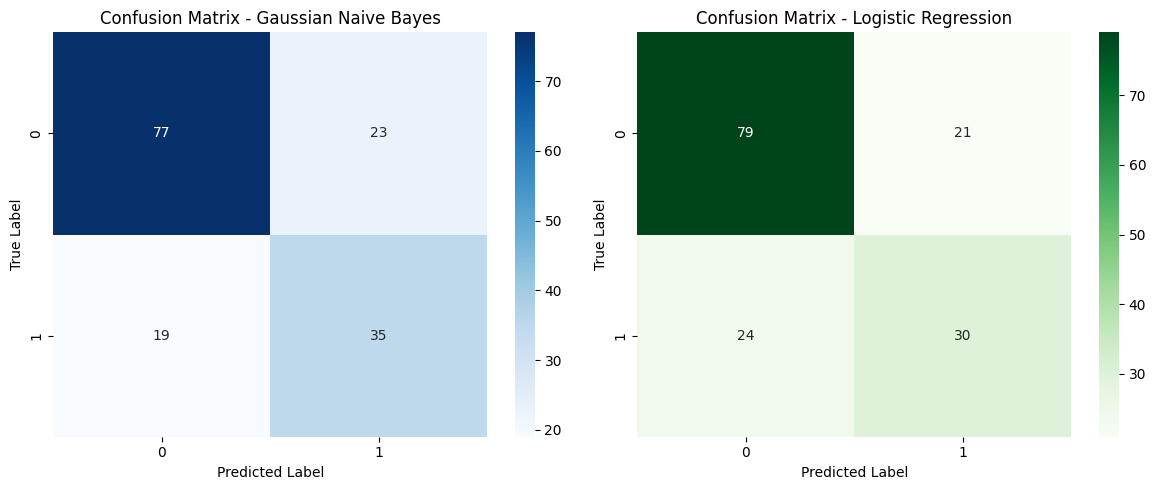

In [37]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 1. Confusion Matrix GNB
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Gaussian Naive Bayes')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
# 2. Confusion Matrix Logistic Regression
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

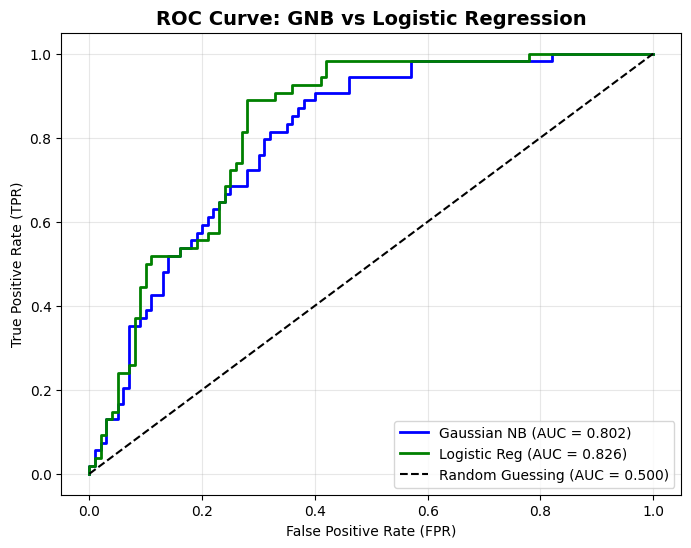

In [38]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
# Menghitung skor AUC (Area Under Curve)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
# Mulai menggambar grafik
plt.figure(figsize=(8, 6))
# Plot kurva kedua model
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB (AUC = {auc_gnb:.3f})', color='blue', linewidth=2)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Reg (AUC = {auc_logreg:.3f})', color='green', linewidth=2)
# Garis putus-putus tebakan acak (batas minimum AUC 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')
plt.title('ROC Curve: GNB vs Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

C:\Users\M S I\AppData\Local\Temp\ipykernel_21052\1566445191.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='RdBu_r')


Text(0, 0.5, 'Fitur')

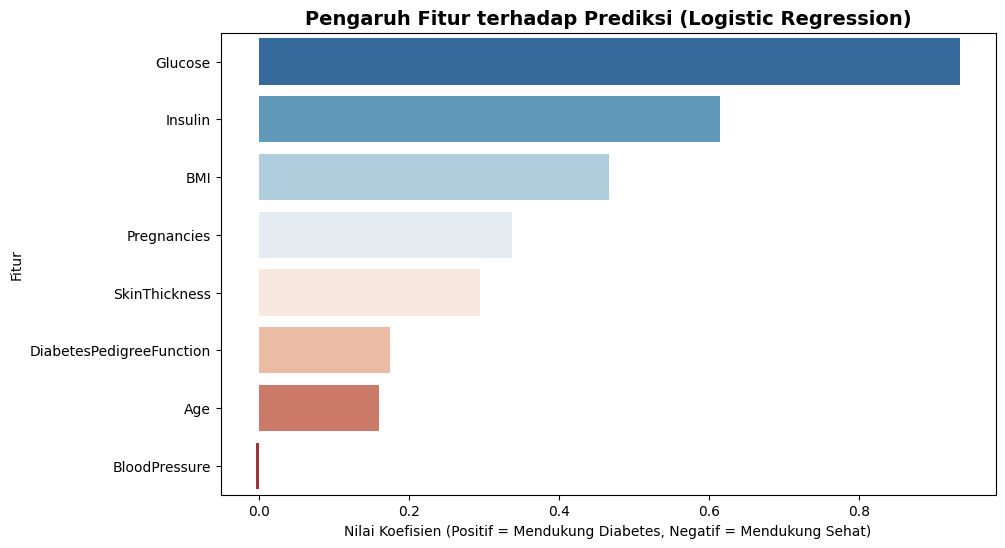

In [39]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_values = logreg.coef_[0]
# Memasukkan ke DataFrame dan diurutkan agar grafiknya rapi
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_values
}).sort_values(by='Coefficient', ascending=False)
# Membuat Bar Chart Horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='RdBu_r')
plt.title('Pengaruh Fitur terhadap Prediksi (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Koefisien (Positif = Mendukung Diabetes, Negatif = Mendukung Sehat)')
plt.ylabel('Fitur')

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Model Gaussian Naive Bayes adalah model yang lebih baik melihat dari hasil training. Dari segi manapun terlihat bahwa GaussianNB berhasil menebak yang seharusnya sakit, memiliki akurasi dalam menebak lebih baik dan diimbangi dengan precision yang lebih tinggi. Kita bisa memutuskan juga GaussianNB lebih baik dari skor f1 yang lebih tinggi juga.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

1. Membuat data balance dahulu dengan menggunakan metode undersampling, SMOTE(disarankan karena data kecil)/OVERSAMPLING, algoritma(untuk coba pertama)
2. Menghapus BloodPressure, Pregnancies, dan DiabetesPedigreeFunction dihapus karena memiliki korelasi yang sangat lemah terhadap target.
3. Perbaikan model pada logistic regression dengan melakukan thresholding pada tebakan probabilitas diabetes
 